In [64]:
import matplotlib.pyplot as plt
from konlpy.tag import Kkma
from konlpy.utils import pprint
import re
from konlpy.tag import Okt
from wordcloud import WordCloud
import pandas as pd

In [65]:
df=pd.read_csv(r'C:\Users\paint\OneDrive\Desktop\Githubproject\Dataviz\데이터 시각화\DemonHunters.csv')

### 기사 제목으로 워드 클라우드 만들기

In [66]:
#title 컬럼의 데이터를 하나의 문자열로 합치기
text=' '.join(df['title'].tolist())

In [67]:
#wordcloud에서 제공하는 영어 불용어
from wordcloud import STOPWORDS
stop_str = [
    "이", "그", "저", "것", "수", "등", "및", "또는",
    "그리고", "하지만", "그러나", "그래서", "즉",
    "에", "에서", "에게", "께", "으로", "로", "와", "과",
    "도", "만", "까지", "부터", "보다", "처럼", "같이",
    "의", "은", "는", "이", "가", "을", "를",
    "하다", "되다", "있다", "없다", "이다","있게",
    "이다", "입니다", "했다", "하였다", "한다",
    "하는", "한", "할",
    "때", "경우", "관련", "대해", "대한",
    "등등", "등의", "등을",'된다',
    "더", "가장", "매우", "아주", "정말",
    "좀", "약간", "다소",
    "같은", "이런", "저런", "그런",
    "여기", "저기", "거기",
    "이미", "아직", "다시",
    "또", "계속", "항상", "보통",
    "왜", "어떻게", "무엇", "어디", "언제",
    "누가", "누구",
]
STOPWORDS.update(stop_str)
STOPWORDS.update(['quot','케데헌','데몬 헌터스','K팝','케이팝 데몬','데몬','케이팝'])
print(STOPWORDS)

{'there', '까지', '거기', "didn't", '다소', "they'd", 'some', 'was', '하다', '되다', '할', 'were', '그', 'those', 'does', 'after', 'such', 'ever', 'off', '것', "here's", 'shall', 'who', 'otherwise', "she'll", 'i', 'each', 'no', 'these', "what's", '하지만', 'only', '에서', '등등', '가장', '저', 'when', '즉', 'below', '아직', '다시', 'www', '무엇', 'her', 'where', '항상', 'and', 'else', 'have', "isn't", 'she', 'to', "we've", "you've", 'it', 'your', 'K팝', 'too', '왜', 'this', '저런', '그런', "why's", '여기', 'into', 'can', '케이팝 데몬', 'they', 'same', 'myself', 'through', "there's", 'like', 'while', '로', '경우', 'cannot', '누구', 'once', 'most', 'own', "can't", 'for', '으로', 'yourselves', '없다', "he's", "it's", "aren't", 'up', '에', '저기', '가', '수', '그리고', 'therefore', 'its', "hasn't", '보통', 'as', '했다', '그래서', 'just', '대해', '보다', '어떻게', 'what', "she'd", 'because', 'do', 'an', '계속', "you're", 'itself', 'could', '와', "you'll", 'been', 'then', 'the', '에게', 'not', "i've", "i'm", '부터', '를', '데몬', '등의', 'be', 'how', 'that', "you'd", 'himself',

In [68]:
from matplotlib import font_manager
font_manager.findSystemFonts()[:10]

['C:\\Windows\\Fonts\\trebucit.ttf',
 'C:\\Windows\\Fonts\\HMFMMUEX.TTC',
 'C:\\Windows\\Fonts\\NIAGENG.TTF',
 'C:\\Windows\\Fonts\\CENTURY.TTF',
 'C:\\Windows\\Fonts\\GILBI___.TTF',
 'C:\\Windows\\Fonts\\Gabriola.ttf',
 'C:\\Users\\paint\\AppData\\Local\\Microsoft\\Windows\\Fonts\\fontawesome5-solid-webfont-5.15.4.ttf',
 'C:\\Windows\\Fonts\\AGENCYR.TTF',
 'C:\\Windows\\Fonts\\malgunsl.ttf',
 'C:\\Windows\\Fonts\\ERASLGHT.TTF']

In [69]:
han_font_path='C:\\Users\\paint\\AppData\\Local\\Microsoft\\Windows\\Fonts\\The Jamsil OTF 4 Medium.otf'

In [70]:
import re

# 텍스트 정제를 위한 함수 정의
def cleanString(text):

    pattern = r"""['"]?([a-z0-9_.+-]+)@([a-z0-9-]+)\.([a-z.]{2,6})['"]?"""
    text = re.sub(pattern=pattern, repl='', string=text)

    # 한글 자음, 모음 제거
    # [ㄱ-ㅎㅏ-ㅣ]+ : 자음 또는 모음이 1개 이상 반복
    pattern = r'[ㄱ-ㅎㅏ-ㅣ]+'
    text = re.sub(pattern=pattern, repl='', string=text)

    # HTML 태그 제거
    # <.*?> : <로 시작하고 >로 끝나는 모든 문자열
    pattern = r'<.*?>'
    text = re.sub(pattern=pattern, repl='', string=text)

    # 특수문자 제거
    # [^\w\s\n] : 영문 대소문자, 숫자, 개행문자가 아닌 문자
    pattern = r'[^\w\s\n]'
    text = re.sub(pattern=pattern, repl='', string=text)

    return text


# 텍스트 정제
text=cleanString(text)


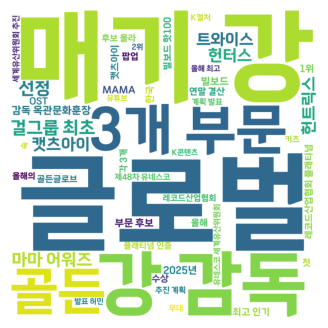

In [71]:
def showwordCloudBasic(wc):
    plt.figure(figsize=(7,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.savefig('워드클라우드.png')
    plt.show()


words_kor=WordCloud(
    max_words=50,
    font_path=han_font_path,
    stopwords=STOPWORDS,
    width=800,
    height=800,
    background_color='white',
    colormap='viridis'
).generate(text)

showwordCloudBasic(words_kor)


In [72]:
from konlpy.tag import Twitter
okt=Okt()
print(f'{okt.nouns(text)=}')

okt.nouns(text)=['유통업', '결산', '생존', '위', '리셋', '해', '격변', '속', '구조', '재', '설계', '총', '키', '라스', '인사동', '플래시몹', '외국인', '관광객', '팝', '체험', '결산', '질주', '넷플릭스', '딜레마', '콘텐츠', '김희', '경의', '컬', '게임', '법칙', '해', '테일러', '스위프트', '빌보드', '통산', '주', '위케데헌', '위스키', '위', '미국', '혈액', '학회', '현장', '컬쳐', '통', '케데헌', '이재', '음악', '이유', '공부', '이', '털', '급', '리조트', '골든', '팝', '침투', '필리핀', '크리스마스', '점등', '현', '아침마당', '화관', '광산업', '활성화', '위', '관련', '기관', '역할', '팝', '한국', '음식', '화장품', '일상', '스', '평균', '나이', '세', '제', '의', '전성기', '국민', '과자', '장수', '비결', '국가', '정상화', '새', '정부', '출범', '코스피', '시대', '뉴스', '선정', '국내', '뉴', '유튜브', '회수', '폭망', '핵심', '키', '워드', '애니', '부재', '토피아', '케데헌', '탄생', '이유', '팝', '저력', '입증', '케데헌', '싱글', '차트', '곡', '동시', '진입', '케데헌', '곡', '싱글차트', '차트', '유지', '골든', '위', '황', '대호', '위원장', '경기도', '컬처', '산업', '육성', '새', '이정표', '것', '기대', '빌보드', '석권', '케데헌', '한국', '노래방', '순위', '키', '라스', '관광객', '만난', '깜짝', '플래시몹', '인사동', '쌈지', '길', '전통', '현대', '아트', '향연', '심장', '수', '조상', '미담', '엔터', '지금', '정작', '한국',

### 기사 내용으로 네트워크 만들기

In [73]:
import pandas as pd
from itertools import combinations
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib
import re
from konlpy.tag import Okt

In [74]:
descriptions=df['description'].tolist()
with open(r'C:\Users\paint\OneDrive\Desktop\Githubproject\Dataviz\데이터 시각화\data\한국어불용어\stopwords-ko.txt','r',encoding='utf-8') as f:
    stopwords=f.read().splitlines()
stopwords.extend(
    ['부문','헌터','스케','올해','수가','수록','quot','케데헌','데몬 헌터스','K팝','케이팝 데몬','데몬','케이팝','헌터스','데헌']
)
all_nouns=[]
for i, text in enumerate(descriptions):
    text_cleaned=re.sub(r'[^가-힣\s]','',text)
    nouns=okt.nouns(text_cleaned)
    nouns=[word for word in set(nouns) if (len(word)>1) and word not in stopwords]
    all_nouns.append(nouns)
print(f'전처리된 단어 목록 : {all_nouns[:5]}')

전처리된 단어 목록 : [['넷플릭스', '북미', '해외', '마케팅', '패키지', '비중', '동남아', '업계', '식품', '농심', '아티스트', '판매량', '협업', '시장', '애니메이션', '오뚜기'], ['퍼포먼스', '인사동', '무대', '플래시몹', '시작', '글로벌', '포함', '발걸음', '관광객', '구성', '외국인'], ['넷플릭스', '증명', '글로벌', '콘텐츠', '예상', '리지', '한국', '이하', '문화', '대표', '흥행', '자체'], ['하반기', '무대', '센세이션', '글로벌', '콘텐츠', '영화', '드라마', '돌풍', '형성', '입증', '대세', '가운데'], ['넷플릭스', '빌보드', '유지', '스트', '그룹', '글로벌', '영화', '키즈', '보이', '간판', '레이', '애니메이션', '신드롬', '스키']]


In [75]:
flat_words = [w for nouns in all_nouns for w in nouns]

# 2) Top 20 계산
top_n = 20
word_counts = Counter(flat_words)
top20 = word_counts.most_common(top_n)

df_top = pd.DataFrame(top20, columns=["keyword", "count"])


In [76]:
df_top

,keyword,count
0,넷플릭스,453
1,애니메이션,440
2,영화,307
3,한국,201
4,미국,192
5,글로벌,181
6,인기,181
7,세계,168
8,콘텐츠,163
9,감독,154


In [ ]:
df_top.to_csv('키워드카운트.csv')

In [78]:
#edge리스트 생성
edge_list=[]
for nouns in all_nouns:
    if len(nouns)>2: # 단어가 2개 이상인 경우에만 처리
        edge_list.extend(combinations(sorted(nouns),2))
edge_counts=Counter(edge_list)
print(edge_counts.most_common(100))

[(('넷플릭스', '애니메이션'), 320), (('애니메이션', '영화'), 213), (('넷플릭스', '영화'), 178), (('미국', '애니메이션'), 124), (('감독', '애니메이션'), 109), (('미국', '영화'), 95), (('감독', '영화'), 92), (('넷플릭스', '세계'), 89), (('애니메이션', '한국'), 86), (('세계', '애니메이션'), 86), (('감독', '박찬욱'), 85), (('넷플릭스', '미국'), 84), (('애니메이션', '후보'), 80), (('소재', '애니메이션'), 80), (('박찬욱', '영화'), 77), (('넷플릭스', '한국'), 75), (('골든글로브', '애니메이션'), 75), (('글로벌', '넷플릭스'), 74), (('영화', '후보'), 74), (('골든글로브', '영화'), 71), (('골든글로브', '후보'), 69), (('애니메이션', '작품'), 68), (('박찬욱', '애니메이션'), 68), (('넷플릭스', '차트'), 65), (('넷플릭스', '인기'), 65), (('감독', '골든글로브'), 65), (('골든글로브', '박찬욱'), 65), (('문화', '한국'), 64), (('콘텐츠', '한국'), 64), (('애니메이션', '인기'), 64), (('감독', '넷플릭스'), 63), (('넷플릭스', '콘텐츠'), 62), (('감독', '후보'), 61), (('박찬욱', '후보'), 61), (('넷플릭스', '리지'), 60), (('영화', '콘텐츠'), 59), (('영화', '작품'), 59), (('미국', '소재'), 59), (('소재', '영화'), 58), (('미국', '후보'), 58), (('넷플릭스', '트릭'), 57), (('넷플릭스', '메인'), 57), (('빌보드', '차트'), 56), (('감독', '미국'), 56), (('세계', '영화'), 56), (('글로벌'

In [79]:
#지정된 최소 빈도 이상의 엣지만 필터링하고 빈도를 weight로 저장하는 딕셔너리 생성
min_count=30
filtered_edges={edge:weight for edge, weight in edge_counts.items() if weight >= min_count}
print(f'필터링된 엣지 개수:{len(filtered_edges)}')
#가장 가중치 높은 엣지 10개 출력
print(f'가장 가중치 높은 edge 10개: \n{sorted(filtered_edges.items(),key= lambda x:x[1],reverse=True)[:10]}')
# 가중치 2 이상만 남기기


필터링된 엣지 개수:143
가장 가중치 높은 edge 10개: 
[(('넷플릭스', '애니메이션'), 320), (('애니메이션', '영화'), 213), (('넷플릭스', '영화'), 178), (('미국', '애니메이션'), 124), (('감독', '애니메이션'), 109), (('미국', '영화'), 95), (('감독', '영화'), 92), (('넷플릭스', '세계'), 89), (('애니메이션', '한국'), 86), (('세계', '애니메이션'), 86)]


In [80]:
#네트워크 그래프 생성
G=nx.Graph()
weighted_edges=[
    (node1,node2,weight) for (node1,node2),weight in filtered_edges.items()
]
G.add_weighted_edges_from(weighted_edges)

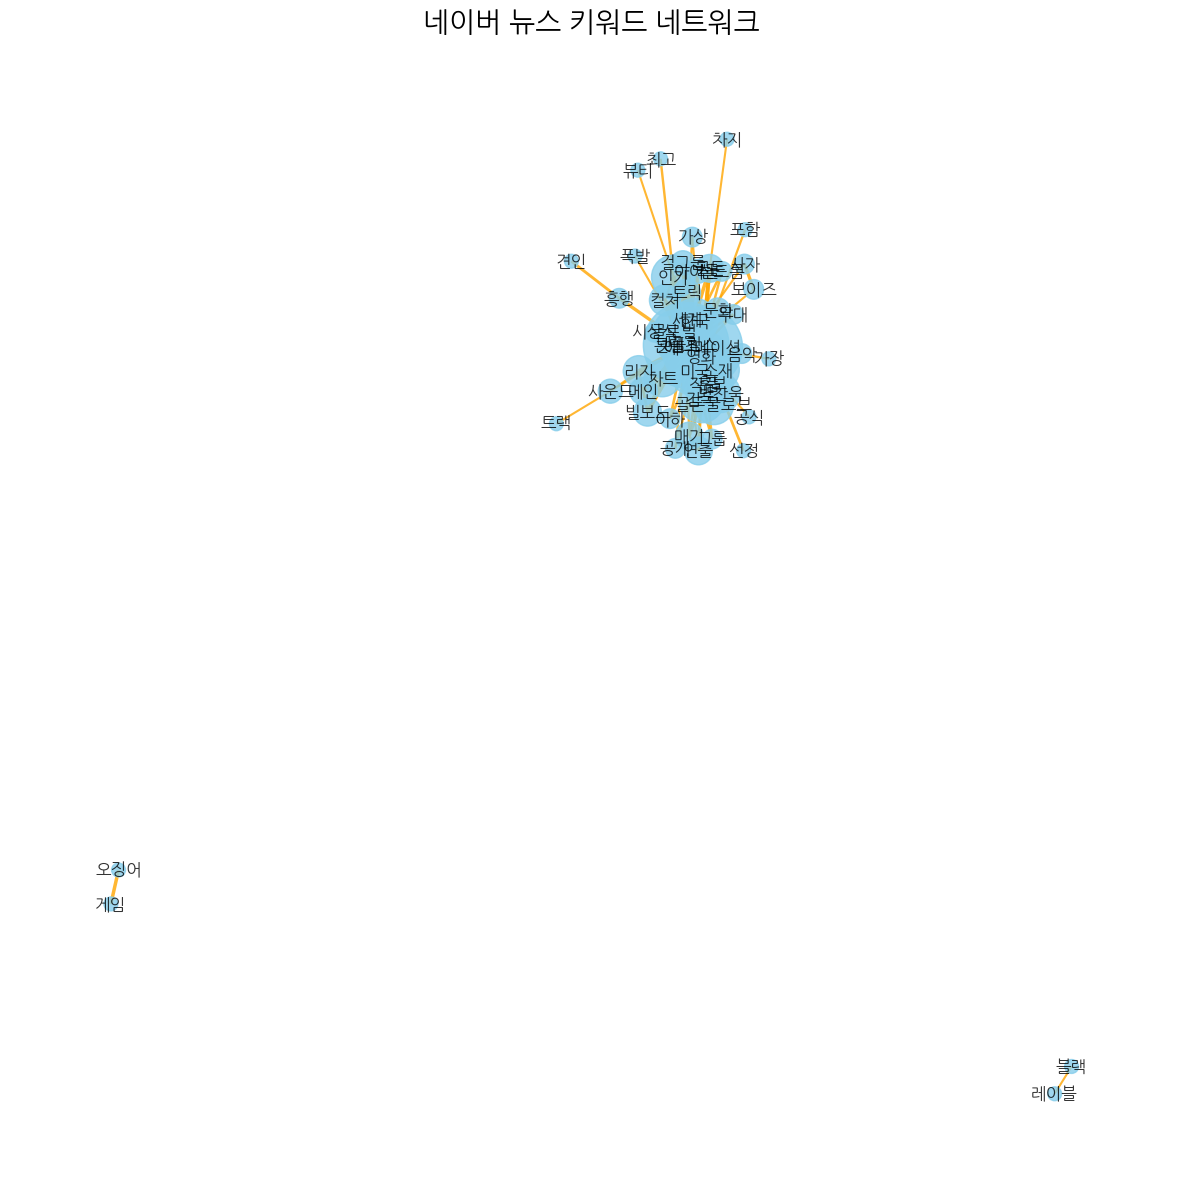

In [81]:
pos_spring=nx.spring_layout(
    G, k=0.3, iterations=50, seed=42
)
#차수기반 노드 크기 설정
node_sizes=[G.degree(node)*100 for node in G.nodes()]
#가중치 기반 엣지 두께 설정
edge_widths=[G[u][v]['weight']*0.05 for u,v in G.edges()]

plt.figure(figsize=(15,15))
nx.draw_networkx(
    G,
    pos_spring,
    with_labels=True,
    node_size=node_sizes,
    width=edge_widths,
    font_family=plt.rcParams['font.family'],
    font_size=12,
    node_color='skyblue',
    edge_color='orange',
    alpha=0.8
)
plt.title('네이버 뉴스 키워드 네트워크',size=20)
plt.axis('off')
plt.show()

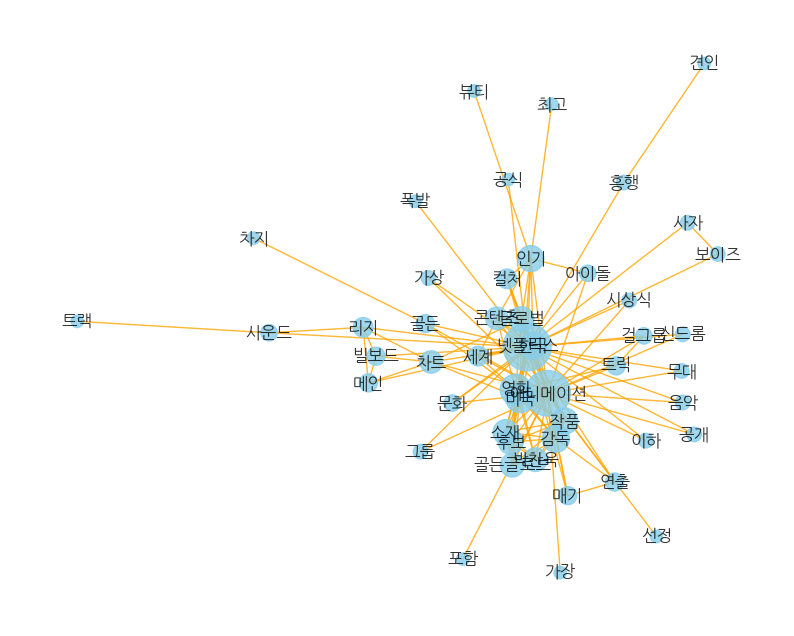

In [82]:
import networkx as nx
import matplotlib.pyplot as plt

# 1) giant component만 추출
components = list(nx.connected_components(G))
giant = max(components, key=len)
G_main = G.subgraph(giant).copy()

# 2) 레이아웃
pos = nx.spring_layout(G_main, seed=42)

# 3) 노드 크기: degree 기반 (원하시면 중심성 등으로도 가능)
deg = dict(G_main.degree())
node_sizes = [50 + 30 * deg[n] for n in G_main.nodes()]

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G_main, pos,
    with_labels=True,
    node_size=node_sizes,
    font_family=plt.rcParams['font.family'],
    font_size=12,
    node_color='skyblue',
    edge_color='orange',
    alpha=0.8
)

plt.axis("off")
plt.savefig('네트워크그래프.png')
plt.show()


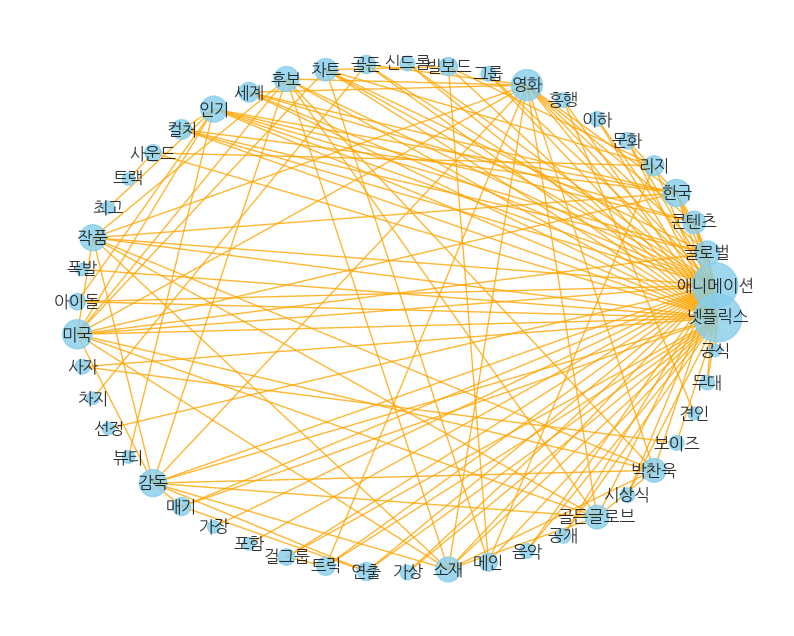

In [83]:
import matplotlib.pyplot as plt
import networkx as nx

pos_circular=nx.circular_layout(G_main)

plt.figure(figsize=(10, 8))

nx.draw_networkx(
    G_main, pos_circular,
    with_labels=True,
    node_size=node_sizes,
    font_family=plt.rcParams['font.family'],
    font_size=12,
    node_color='skyblue',
    edge_color='orange',
    alpha=0.8
)

plt.axis("off")
plt.savefig('circulara_네트워크.png')
plt.show()
